# Wind speed and direction

Explore Boston buoy winds, plot speed and gusts, and average directions without losing the 0/360-degree boundary.

The download cell records when the observations were retrieved.

NOAA defines WDIR as the direction the wind **comes from**, clockwise from true north: 0/360° is north, 90° east, 180° south, and 270° west. `WSPD` and `GST` are in metres per second. Wind measurements depend on station instrumentation and averaging periods; these examples do not adjust winds to a standard height. See [NOAA’s measurement definitions](https://www.ndbc.noaa.gov/faq/measdes.shtml) for sampling conventions.

In [1]:
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xndbc

station_id = "44013"
year = 2020
data = xndbc.historical(station_id, years=year, progress=False)
print("Retrieved:", datetime.now(timezone.utc).isoformat())
data.ndbc.report()

Retrieved: 2026-09-10T14:52:42.181505+00:00


<xarray.Dataset> Size: 332B
Dimensions:     (request: 1)
Coordinates:
  * request     (request) int64 8B 0
Data variables:
    station_id  (request) <U5 20B '44013'
    url         (request) <U66 264B 'https://www.ndbc.noaa.gov/data/historica...
    status      (request) <U7 28B 'success'
    error       (request) <U1 4B ''
    year        (request) float64 8B 2.02e+03
Attributes:
    description:  Original download request outcomes; year is missing for rea...

## Select the wind measurements

Keep original observations and metadata. Missing NOAA values are already represented as NaN. Plot the first week separately so individual observations remain visible.

In [2]:
wind = data[["WSPD", "GST", "WDIR"]].sel(station_id=station_id)
wind

<xarray.Dataset> Size: 520kB
Dimensions:       (time: 16103)
Coordinates:
  * time          (time) datetime64[us] 129kB 2019-12-31T23:50:00 ... 2020-12...
    station_id    <U5 20B '44013'
    latitude      float64 8B 42.35
    longitude     float64 8B -70.65
    name          <U76 304B 'BOSTON 16 NM East of Boston, MA'
    owner         <U3 12B 'N'
    station_type  <U40 160B '2.1-meter ionomer foam buoy'
    notes         <U990 4kB 'Caution: Right whales may be active in northeast...
Data variables:
    WSPD          (time) float64 129kB 5.4 5.3 7.1 7.7 7.8 ... 6.9 7.1 7.7 8.1
    GST           (time) float64 129kB 7.0 6.9 9.3 10.0 ... 8.5 9.2 10.0 10.0
    WDIR          (time) float64 129kB 295.0 276.0 257.0 ... 301.0 300.0 300.0
Attributes:
    source:        NOAA National Data Buoy Center
    feed:          historical
    ndbc_mode:     stdmet
    retrieved_at:  2026-09-10T14:52:42.181176+00:00
    ndbc_report:   [{"station_id": "44013", "year": 2020, "url": "https://www...
    sampling:      Original observations; no temporal resampling

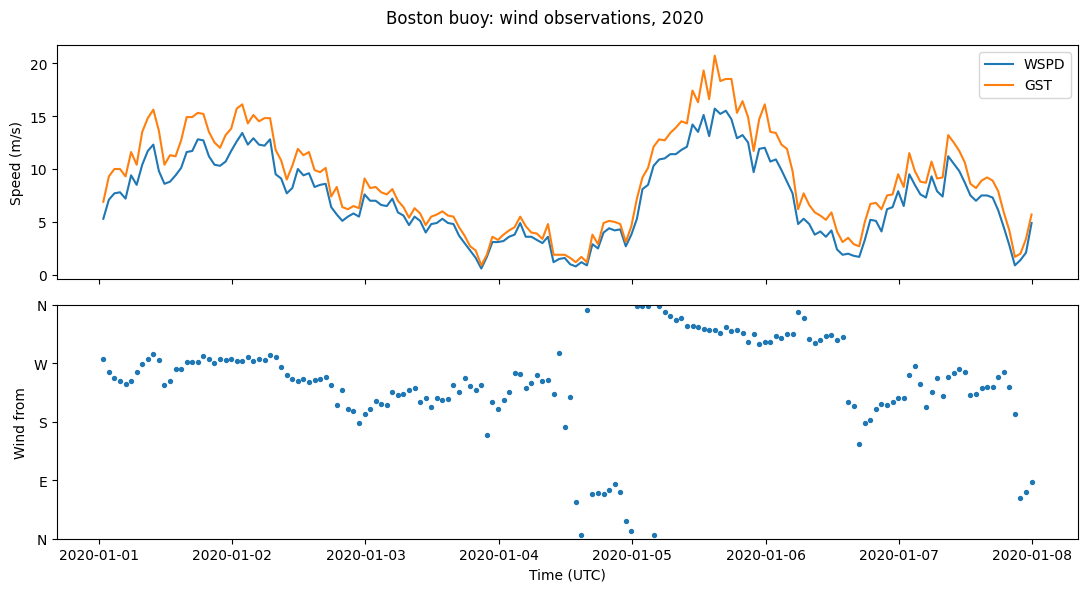

In [3]:
week = wind.sel(time=slice(f"{year}-01-01", f"{year}-01-07"))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for name in ["WSPD", "GST"]:
    axes[0].plot(week.time, week[name], label=name)
axes[0].set_ylabel("Speed (m/s)")
axes[0].legend()
# Points avoid drawing a line across north when direction crosses 0/360.
axes[1].scatter(week.time, week.WDIR.where(week.WSPD > 0), s=8)
axes[1].set_yticks([0, 90, 180, 270, 360], ["N", "E", "S", "W", "N"])
axes[1].set_ylim(0, 360)
axes[1].set_ylabel("Wind from")
axes[1].set_xlabel("Time (UTC)")
fig.suptitle(f"Boston buoy: wind observations, {year}")
fig.tight_layout()
plt.show()

## Average speeds and directions by day

Arithmetic means work for speed. For direction, 350° and 10° average to north, not south. Average the sine and cosine instead. Use positive speeds with valid directions for the direction mean, excluding calm winds whose direction is undefined. Speed means use all valid speeds, so their sample count can differ.

The resultant length ranges from zero to one: values near one indicate clustered directions; values near zero indicate cancellation. Mask an undefined mean when the resultant is effectively zero. Each observation has equal weight; these are sample means, not duration-weighted means when sampling is irregular. The circular mean weights each valid direction equally, not by wind speed.

In [4]:
daily_speed = wind.WSPD.resample(time="D").mean(keep_attrs=True)
direction_samples = wind.WDIR.where((wind.WSPD > 0) & wind.WDIR.notnull())
radians = np.deg2rad(direction_samples)
sine = np.sin(radians).resample(time="D").mean()
cosine = np.cos(radians).resample(time="D").mean()
resultant = np.hypot(sine, cosine)
daily_direction = (np.rad2deg(np.arctan2(sine, cosine)) % 360).where(resultant > 1e-12)
daily_direction.attrs = {"long_name": "Daily circular mean wind direction", "units": "degree"}
summary = xr.Dataset({
    "mean_speed": daily_speed,
    "mean_direction": daily_direction,
    "direction_resultant": resultant,
    "speed_samples": wind.WSPD.resample(time="D").count(),
    "direction_samples": direction_samples.resample(time="D").count(),
})
summary

<xarray.Dataset> Size: 22kB
Dimensions:              (time: 367)
Coordinates:
  * time                 (time) datetime64[us] 3kB 2019-12-31 ... 2020-12-31
    station_id           <U5 20B '44013'
    latitude             float64 8B 42.35
    longitude            float64 8B -70.65
    name                 <U76 304B 'BOSTON 16 NM East of Boston, MA'
    owner                <U3 12B 'N'
    station_type         <U40 160B '2.1-meter ionomer foam buoy'
    notes                <U990 4kB 'Caution: Right whales may be active in no...
Data variables:
    mean_speed           (time) float64 3kB 5.4 9.883 9.125 ... 7.709 8.801
    mean_direction       (time) float64 3kB 295.0 264.0 245.8 ... 258.4 246.1
    direction_resultant  (time) float64 3kB 1.0 0.9678 0.8671 ... 0.758 0.8293
    speed_samples        (time) int64 3kB 1 24 24 24 24 ... 144 144 144 144 144
    direction_samples    (time) int64 3kB 1 24 24 24 24 ... 144 144 144 144 144

## Calculate the mean wind vector

To describe average air motion, convert each observation into eastward (`u`) and northward (`v`) velocity before averaging. The minus signs convert the meteorological **from** direction into motion **toward** a direction:

`u = -speed * sin(direction)` and `v = -speed * cos(direction)`.

Use the same valid samples for both components. A measured zero speed contributes a zero vector even if direction is missing. A positive speed with missing direction contributes neither component. Opposing winds can cancel, so the magnitude of the mean vector can be smaller than the mean scalar speed. The vector's direction is undefined when its magnitude is effectively zero. Its magnitude is at most the mean scalar speed calculated over the same paired samples.

In [5]:
angle = np.deg2rad(wind.WDIR)
valid = wind.WSPD.notnull() & ((wind.WSPD == 0) | wind.WDIR.notnull())
u = xr.where(wind.WSPD == 0, 0.0, -wind.WSPD * np.sin(angle)).where(valid)
v = xr.where(wind.WSPD == 0, 0.0, -wind.WSPD * np.cos(angle)).where(valid)
u_daily = u.resample(time="D").mean()
v_daily = v.resample(time="D").mean()
vector_speed = np.hypot(u_daily, v_daily)
vector_direction = (np.rad2deg(np.arctan2(-u_daily, -v_daily)) % 360).where(vector_speed > 1e-12)
vector = xr.Dataset({
    "u": u_daily,
    "v": v_daily,
    "speed": vector_speed,
    "direction": vector_direction,
    "paired_scalar_speed": wind.WSPD.where(valid).resample(time="D").mean(),
    "samples": u.resample(time="D").count(),
})
for name in ["u", "v", "speed", "paired_scalar_speed"]:
    vector[name].attrs["units"] = "m s-1"
vector.direction.attrs = {"long_name": "Mean vector wind from direction", "units": "degree"}
vector

<xarray.Dataset> Size: 25kB
Dimensions:              (time: 367)
Coordinates:
  * time                 (time) datetime64[us] 3kB 2019-12-31 ... 2020-12-31
    station_id           <U5 20B '44013'
    latitude             float64 8B 42.35
    longitude            float64 8B -70.65
    name                 <U76 304B 'BOSTON 16 NM East of Boston, MA'
    owner                <U3 12B 'N'
    station_type         <U40 160B '2.1-meter ionomer foam buoy'
    notes                <U990 4kB 'Caution: Right whales may be active in no...
Data variables:
    u                    (time) float64 3kB 4.894 9.562 7.767 ... 5.792 6.533
    v                    (time) float64 3kB -2.282 0.6981 2.307 ... 0.7121 3.259
    speed                (time) float64 3kB 5.4 9.588 8.103 ... 5.835 7.301
    direction            (time) float64 3kB 295.0 265.8 253.5 ... 263.0 243.5
    paired_scalar_speed  (time) float64 3kB 5.4 9.883 9.125 ... 7.709 8.801
    samples              (time) int64 3kB 1 24 24 24 24 ... 144 144 144 144 144

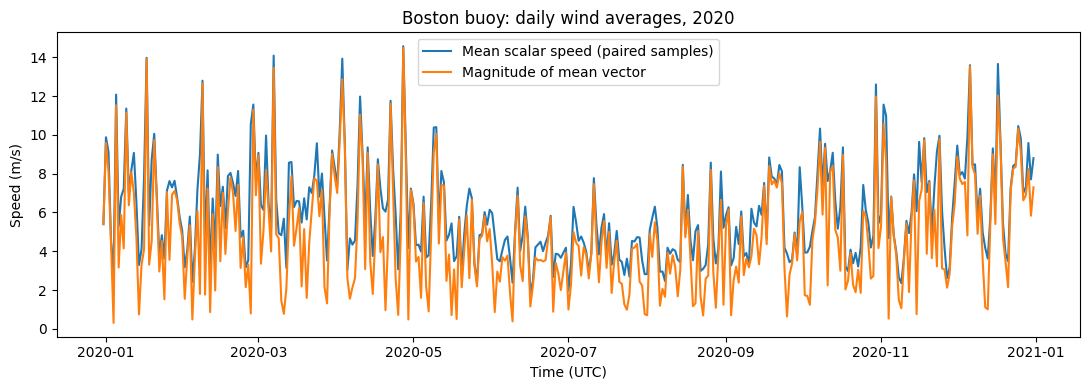

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vector.time, vector.paired_scalar_speed, label="Mean scalar speed (paired samples)")
ax.plot(vector.time, vector.speed, label="Magnitude of mean vector")
ax.set(xlabel="Time (UTC)", ylabel="Speed (m/s)", title=f"Boston buoy: daily wind averages, {year}")
ax.legend()
fig.tight_layout()
plt.show()

## Check coverage before interpreting averages

Count days containing at least one valid observation over the full requested year. This is occupied-day coverage, not the fraction of expected native samples. Inspect the sample counts above as well: a daily average based on one observation need not represent the full day.

In [7]:
data[["WSPD", "WDIR"]].ndbc.coverage(
    "D", start=f"{year}-01-01", end=f"{year}-12-31T23:59:59"
)

<xarray.Dataset> Size: 4kB
Dimensions:       (station_id: 1)
Coordinates:
  * station_id    (station_id) object 8B '44013'
    latitude      (station_id) float64 8B 42.35
    longitude     (station_id) float64 8B -70.65
    name          (station_id) <U76 304B 'BOSTON 16 NM East of Boston, MA'
    owner         (station_id) <U3 12B 'N'
    station_type  (station_id) <U40 160B '2.1-meter ionomer foam buoy'
    notes         (station_id) <U990 4kB 'Caution: Right whales may be active...
Data variables:
    WSPD          (station_id) float64 8B 100.0
    WDIR          (station_id) float64 8B 100.0
Attributes:
    frequency:     D
    window_start:  2020-01-01T00:00:00.000000000
    window_end:    2020-12-31T23:59:59.000000000
    time_bins:     366
    definition:    Percent of bins containing at least one nonmissing observa...